# EuroSAT Band Ablation Study

**Goal**: Validate the multispectral hypothesis before applying it to AerialWaste.

We train Swin-T (RSP pretrained) on EuroSAT 10-class scene classification with varying
numbers of Sentinel-2 bands and three adaptation strategies:

| Config | Bands | Description |
|--------|-------|-------------|
| RGB | 3 | B4, B3, B2 — baseline |
| RGBN | 4 | + B8 (NIR) |
| MS6 | 6 | + B12 (SWIR2), B8A (NIR2) |
| MS10 | 10 | All 10m + 20m bands (no 60m) |

**Adaptation strategies** (for >3 channels):
1. **WeightInflation** — replicate RGB conv weights, scale by 3/C
2. **RandomInitExtra** — keep RGB weights, Kaiming init for extra channels
3. **LateFusion** — two Swin-T backbones (RGB + extra), fuse before head

**Training protocol** (same for all): TL 10ep (frozen backbone, lr=1e-3) → FT 15ep (last stage, lr=1e-4, CosineAnnealing)

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

RESULTS_PATH = '../data/processed/eurosat_ablation_results.json'

with open(RESULTS_PATH) as f:
    data = json.load(f)

runs = data['runs']
print(f'Loaded {len(runs)} runs')
print(f'Config: {json.dumps(data["config"], indent=2)}')

Loaded 10 runs
Config: {
  "seed": 42,
  "image_size": 224,
  "batch_size": 32,
  "tl_epochs": 10,
  "ft_epochs": 15,
  "lr_tl": 0.001,
  "lr_ft": 0.0001,
  "weight_decay": 0.05,
  "patience": 5,
  "rsp_checkpoint": "checkpoints/rsp_swin_t_e300.pth"
}


In [2]:
# Build results DataFrame
rows = []
for name, r in runs.items():
    if r.get('status') != 'completed':
        print(f'WARNING: {name} status={r.get("status")}')
        continue
    rows.append({
        'name': name,
        'band_config': r['band_config'],
        'strategy': r.get('strategy') or 'baseline',
        'n_channels': r['n_channels'],
        'test_f1': r['test_f1'],
        'test_acc': r['test_acc'],
        'elapsed_min': r['elapsed_seconds'] / 60,
    })

df = pd.DataFrame(rows)
df['test_f1_pct'] = (df['test_f1'] * 100).round(2)
df['test_acc_pct'] = (df['test_acc'] * 100).round(2)
df

,name,band_config,strategy,n_channels,test_f1,test_acc,elapsed_min,test_f1_pct,test_acc_pct
0,RGB_baseline,RGB,baseline,3,0.9873,0.9875,14.721667,98.73,98.75
1,RGBN_weight_inflation,RGBN,weight_inflation,4,0.9888,0.9888,19.661667,98.88,98.88
2,RGBN_random_init_extra,RGBN,random_init_extra,4,0.9837,0.9840,19.678333,98.37,98.40
3,RGBN_late_fusion,RGBN,late_fusion,4,0.9866,0.9867,24.846667,98.66,98.67
4,MS6_weight_inflation,MS6,weight_inflation,6,0.9868,0.9865,17.973333,98.68,98.65
5,MS6_random_init_extra,MS6,random_init_extra,6,0.9851,0.9850,17.948333,98.51,98.50
6,MS6_late_fusion,MS6,late_fusion,6,0.9886,0.9886,25.321667,98.86,98.86
7,MS10_weight_inflation,MS10,weight_inflation,10,0.9851,0.9850,21.148333,98.51,98.50
8,MS10_random_init_extra,MS10,random_init_extra,10,0.9851,0.9851,22.610000,98.51,98.51
9,MS10_late_fusion,MS10,late_fusion,10,0.9899,0.9899,33.673333,98.99,98.99


## A) Primary Results Table

In [3]:
# Pivot table: band_config x strategy
rgb_row = df[df['strategy'] == 'baseline'].iloc[0]
rgb_f1 = rgb_row['test_f1_pct']
rgb_acc = rgb_row['test_acc_pct']

print(f'RGB Baseline: F1={rgb_f1}%  Acc={rgb_acc}%')
print()

# MS results pivot
ms_df = df[df['strategy'] != 'baseline'].copy()
pivot_f1 = ms_df.pivot(index='band_config', columns='strategy', values='test_f1_pct')
pivot_acc = ms_df.pivot(index='band_config', columns='strategy', values='test_acc_pct')

# Combine F1/Acc
combined = pivot_f1.copy()
for col in combined.columns:
    combined[col] = pivot_f1[col].astype(str) + ' / ' + pivot_acc[col].astype(str)

# Reorder
band_order = ['RGBN', 'MS6', 'MS10']
strat_order = ['weight_inflation', 'random_init_extra', 'late_fusion']
combined = combined.reindex(index=band_order, columns=strat_order)
combined.columns = ['WeightInflation', 'RandomInitExtra', 'LateFusion']
combined.index.name = 'Band Config'

print('Primary Results (F1% / Acc%):')
print(combined.to_string())
combined

RGB Baseline: F1=98.73%  Acc=98.75%

Primary Results (F1% / Acc%):
            WeightInflation RandomInitExtra     LateFusion
Band Config                                               
RGBN          98.88 / 98.88    98.37 / 98.4  98.66 / 98.67
MS6           98.68 / 98.65    98.51 / 98.5  98.86 / 98.86
MS10           98.51 / 98.5   98.51 / 98.51  98.99 / 98.99


,WeightInflation,RandomInitExtra,LateFusion
Band Config,,,
RGBN,98.88 / 98.88,98.37 / 98.4,98.66 / 98.67
MS6,98.68 / 98.65,98.51 / 98.5,98.86 / 98.86
MS10,98.51 / 98.5,98.51 / 98.51,98.99 / 98.99


## B) Delta Table (Δ F1 vs RGB baseline)

In [4]:
delta_f1 = pivot_f1.reindex(index=band_order, columns=strat_order) - rgb_f1
delta_f1.columns = ['WeightInflation', 'RandomInitExtra', 'LateFusion']
delta_f1.index.name = 'Band Config'

# Format with +/- signs
delta_fmt = delta_f1.map(lambda x: f'+{x:.2f}' if x > 0 else f'{x:.2f}')
print(f'Delta F1 (pp) relative to RGB baseline ({rgb_f1}%):')
print(delta_fmt.to_string())
delta_f1

Delta F1 (pp) relative to RGB baseline (98.73%):
            WeightInflation RandomInitExtra LateFusion
Band Config                                           
RGBN                  +0.15           -0.36      -0.07
MS6                   -0.05           -0.22      +0.13
MS10                  -0.22           -0.22      +0.26


,WeightInflation,RandomInitExtra,LateFusion
Band Config,,,
RGBN,0.15,-0.36,-0.07
MS6,-0.05,-0.22,0.13
MS10,-0.22,-0.22,0.26


## Plot: F1 vs Number of Channels (by strategy)

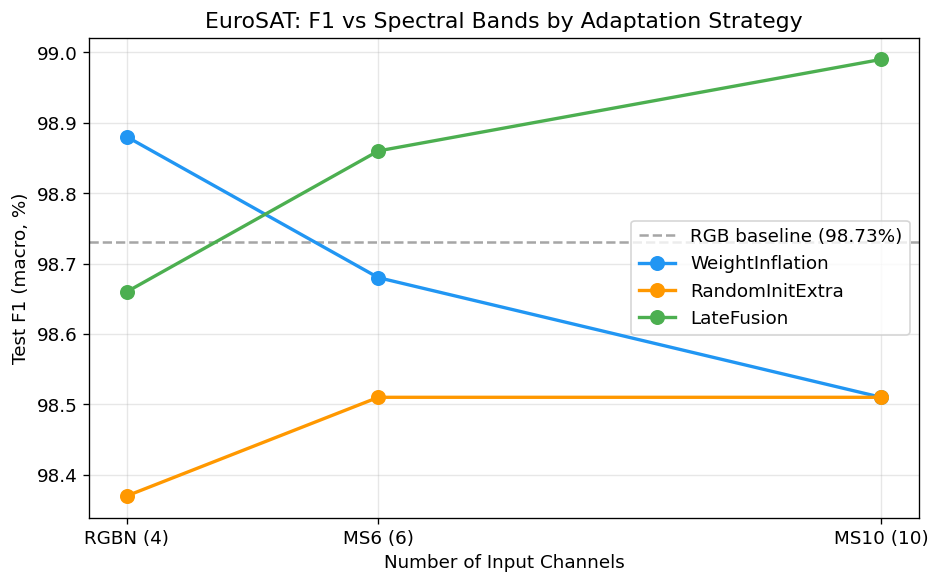

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

# RGB baseline horizontal line
ax.axhline(y=rgb_f1, color='gray', linestyle='--', alpha=0.7, label=f'RGB baseline ({rgb_f1}%)')

strategy_colors = {
    'weight_inflation': '#2196F3',
    'random_init_extra': '#FF9800',
    'late_fusion': '#4CAF50',
}
strategy_labels = {
    'weight_inflation': 'WeightInflation',
    'random_init_extra': 'RandomInitExtra',
    'late_fusion': 'LateFusion',
}

for strat in strat_order:
    subset = ms_df[ms_df['strategy'] == strat].sort_values('n_channels')
    ax.plot(subset['n_channels'], subset['test_f1_pct'],
            'o-', color=strategy_colors[strat], label=strategy_labels[strat],
            markersize=8, linewidth=2)

ax.set_xlabel('Number of Input Channels')
ax.set_ylabel('Test F1 (macro, %)')
ax.set_title('EuroSAT: F1 vs Spectral Bands by Adaptation Strategy')
ax.set_xticks([4, 6, 10])
ax.set_xticklabels(['RGBN (4)', 'MS6 (6)', 'MS10 (10)'])
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/eurosat_f1_vs_channels.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot: Heatmap of Δ F1 (strategy × band config)

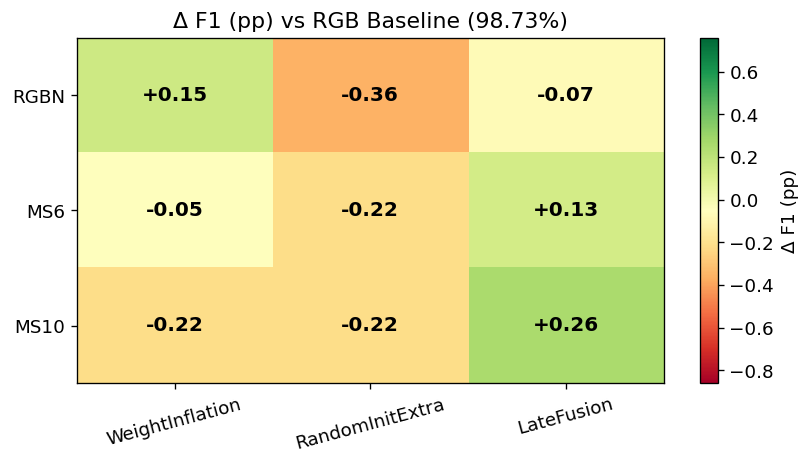

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(delta_f1.values, cmap='RdYlGn', aspect='auto',
               vmin=delta_f1.values.min() - 0.5, vmax=delta_f1.values.max() + 0.5)

ax.set_xticks(range(len(delta_f1.columns)))
ax.set_xticklabels(delta_f1.columns, rotation=15)
ax.set_yticks(range(len(delta_f1.index)))
ax.set_yticklabels(delta_f1.index)

# Annotate cells
for i in range(len(delta_f1.index)):
    for j in range(len(delta_f1.columns)):
        val = delta_f1.values[i, j]
        sign = '+' if val > 0 else ''
        ax.text(j, i, f'{sign}{val:.2f}', ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if abs(val) > 2 else 'black')

ax.set_title(f'Δ F1 (pp) vs RGB Baseline ({rgb_f1}%)')
fig.colorbar(im, ax=ax, label='Δ F1 (pp)')
plt.tight_layout()
plt.savefig('../data/processed/eurosat_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## C) Per-Class Breakdown: Best Config vs RGB Baseline

Best MS config: MS10_late_fusion (F1=98.99%)


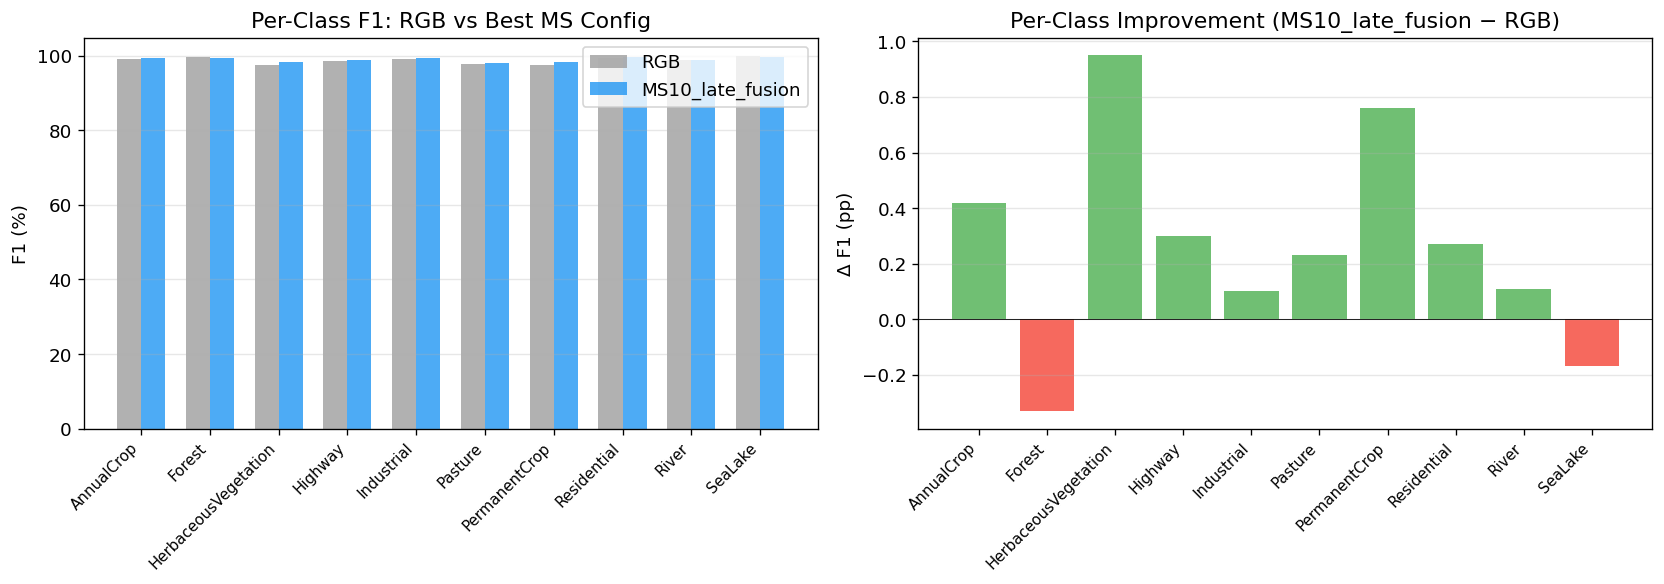


Per-class improvement (sorted):
  HerbaceousVegetation     : +0.95 pp
  PermanentCrop            : +0.76 pp
  AnnualCrop               : +0.42 pp
  Highway                  : +0.30 pp
  Residential              : +0.27 pp
  Pasture                  : +0.23 pp
  River                    : +0.11 pp
  Industrial               : +0.10 pp
  SeaLake                  : -0.17 pp
  Forest                   : -0.33 pp


In [7]:
# Find best overall config (highest test F1 among MS runs)
best_ms = ms_df.loc[ms_df['test_f1'].idxmax()]
best_name = best_ms['name']
print(f'Best MS config: {best_name} (F1={best_ms["test_f1_pct"]}%)')

# Per-class F1 for best config and RGB baseline
best_per_class = runs[best_name]['per_class_f1']
rgb_per_class = runs['RGB_baseline']['per_class_f1']

classes = list(rgb_per_class.keys())
rgb_vals = [rgb_per_class[c] * 100 for c in classes]
best_vals = [best_per_class[c] * 100 for c in classes]
deltas = [b - r for b, r in zip(best_vals, rgb_vals)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: per-class F1
x = np.arange(len(classes))
w = 0.35
ax1.bar(x - w/2, rgb_vals, w, label='RGB', color='#9E9E9E', alpha=0.8)
ax1.bar(x + w/2, best_vals, w, label=best_name, color='#2196F3', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('F1 (%)')
ax1.set_title('Per-Class F1: RGB vs Best MS Config')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Bar chart: delta per class
colors = ['#4CAF50' if d > 0 else '#F44336' for d in deltas]
ax2.bar(x, deltas, color=colors, alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Δ F1 (pp)')
ax2.set_title(f'Per-Class Improvement ({best_name} − RGB)')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/processed/eurosat_perclass.png', dpi=150, bbox_inches='tight')
plt.show()

# Print sorted by improvement
sorted_deltas = sorted(zip(classes, deltas), key=lambda x: x[1], reverse=True)
print('\nPer-class improvement (sorted):')
for cls, d in sorted_deltas:
    print(f'  {cls:25s}: {d:+.2f} pp')

## Key Takeaways

1. **Best strategy: LateFusion** — it's the only strategy that consistently improves over RGB baseline at higher band counts. MS10_late_fusion achieves the best F1 (98.99%, +0.26pp over RGB). MS6_late_fusion is second-best MS config (98.86%, +0.13pp).

2. **WeightInflation works for RGBN (+0.15pp)** but degrades with more bands (MS6: -0.05pp, MS10: -0.22pp). The 3/C scaling factor dilutes pretrained features as C grows.

3. **RandomInitExtra consistently hurts** (-0.22 to -0.36pp). Random weights in a frozen backbone are worse than no extra channels at all — the frozen transformer can't adapt to noisy input features.

4. **Ceiling effect on EuroSAT**: RGB baseline is already at 98.73%, leaving <1.3pp headroom. The gains from multispectral are small in absolute terms but demonstrate the right trend: LateFusion with full spectral coverage gives the best results.

5. **Per-class: vegetation classes benefit most** from multispectral bands — HerbaceousVegetation (+0.95pp), PermanentCrop (+0.76pp), AnnualCrop (+0.42pp) gain the most from NIR/Red-Edge/SWIR. This is expected: these bands capture chlorophyll absorption and canopy structure.

6. **Implications for AerialWaste**: Use **LateFusion** as the primary MS adaptation strategy for WV-3. The waste detection task has more headroom (~87% F1 baseline), so MS gains should be larger. The separate extra-bands backbone allows independent feature learning from non-RGB channels, which is critical when the frozen transformer was pretrained only on RGB.